# MiniGPT — Testing / Generation

In [ ]:
from src.config import Config
from src.model import MiniGPT
from src.data import CharTokenizer, prepare_data
from src.utils import load_checkpoint, perplexity, generate, plot_embedding_pca, plot_embedding_pca_classified
from src.train import estimate_loss
import torch.nn as nn
from pathlib import Path

import matplotlib.pyplot as plt

config = Config()
device = config.device
print("Device:", device)

PROJECT_ROOT = Path("./")

Device: cuda


In [3]:
checkpoint_path = PROJECT_ROOT / "models" / "mini_gpt_best.pth"

model, checkpoint = load_checkpoint(
    str(checkpoint_path),
    MiniGPT,
    device
)

checkpoint_config = checkpoint["config"]
tokenizer = CharTokenizer.from_state_dict(checkpoint["tokenizer"])

print("Checkpoint loaded successfully.")
print("Training iteration:", checkpoint["iteration"])
print("Best validation loss:", checkpoint["best_val_loss"])
print("Vocabulary size:", tokenizer.vocab_size)

Checkpoint loaded successfully.
Training iteration: 1750
Best validation loss: 2.266861915588379
Vocabulary size: 70


In [5]:
_, _, train_data, val_data = prepare_data(
    path=str(PROJECT_ROOT / checkpoint_config["data_path"]),
    fraction=checkpoint_config["data_fraction"],
    train_split=checkpoint_config["train_split"]
)

Original length: 227566049
Cleaned length: 226462031
Vocabulary size: 70
['\n', ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', '?', '@', '[', '\\', ']', '^', '_', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '|', '}', '~']
Train characters: 203815827
Validation characters: 22646204


In [11]:
prompt = "her knowledge was not very extended, she knew two things which only genius knows. The one was humanity, and the other was art"

print(generate(
    model=model,
    prompt=prompt,
    tokenizer=tokenizer,
    block_size=checkpoint_config["block_size"],
    device=device,
    max_new_tokens=400,
    temperature=1.0
))

her knowledge was not very extended, she knew two things which only genius knows. the one was humanity, and the other was art a
my kvof tron hiteled alss davang che tled ievinshs at oteaid, bry mis
zotin ore ire toff upmatt ntor wolang tt preeasetes
, asat poul s asjarezie. ale ird cre thise shedrrsstuat te& ound
ons; isawhe is do
| myotht henn the r
opoue sh brasts wathined at flm thend winct a thesir tornalas a thecen whz some
fet parewhictincily, alosiolat mit an
[n thirin, frd buenithotiald tin urth, pseledo wit the


In [12]:
print("\033[1m\n\nConservative\n\033[0m")
print(generate(
    model, prompt, tokenizer,
    checkpoint_config["block_size"], device,
    400, temperature=0.5
))

print("\033[1m\n\nMore Random\n\033[0m")
print(generate(
    model, prompt, tokenizer,
    checkpoint_config["block_size"], device,
    400, temperature=1.5
))

print("\033[1m\n\nTop K Sampling\n\033[0m")
print(generate(
    model, prompt, tokenizer,
    checkpoint_config["block_size"], device,
    400, temperature=0.8, top_k=10
))



Conservative

her knowledge was not very extended, she knew two things which only genius knows. the one was humanity, and the other was art me
then wit be feror this ar thang an the paind f the the helat is be mand the and the and
the out wo he brof the an hand the he bla and theres ind iche he and hengn ind anther san of thand thind the he she anthe an and
ther perinen as fof an bmithe tt
the the hende prere his or ward the he heand when tr anaf there ther the wad tof this de y anore oullon hend and
and the the wind she thele wis th


More Random

her knowledge was not very extended, she knew two things which only genius knows. the one was humanity, and the other was artbk8 f y
inot;l. i pbyag, wok,otld s an wacute ke$4]bouthiod,>{
dat ai>. ilfo t hyoo _lfott! is yeppiecht rindy thipunglungthed. ug. axyed.
gcrd:,ow-ad= tkrd tilotnyefats, oz.-? whrshrlyeran, oangy,936l_;|3pely; v\sl,: 1ofi. s nnan'trcotltse dal - $:15~

pnonepho' m,
vesesverf.
 alad days-! sa 94ptt. 26 esdablbivje= y

Embedding shape: (70, 384)
PCA shape: (70, 2)
Explained variance: [0.12297947 0.09513546]
Total explained variance: 21.81%


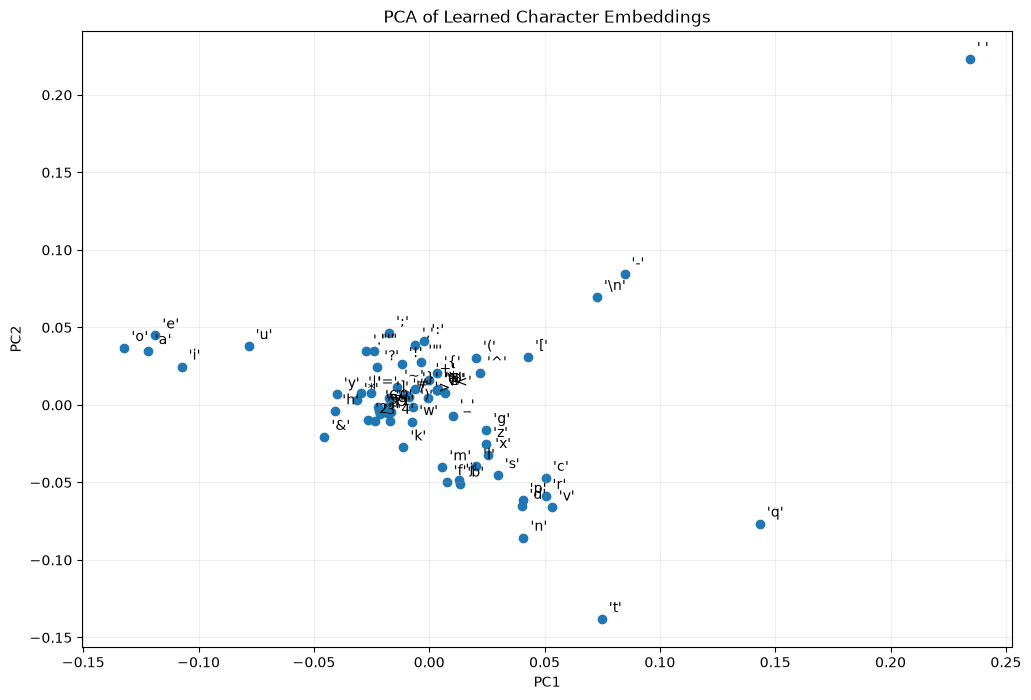

In [7]:
plot_embedding_pca(model=model, tokenizer=tokenizer)

Embedding shape: (70, 384)
PCA shape: (70, 2)
Explained variance: [0.12297947 0.09513546]
Total explained variance: 21.81%


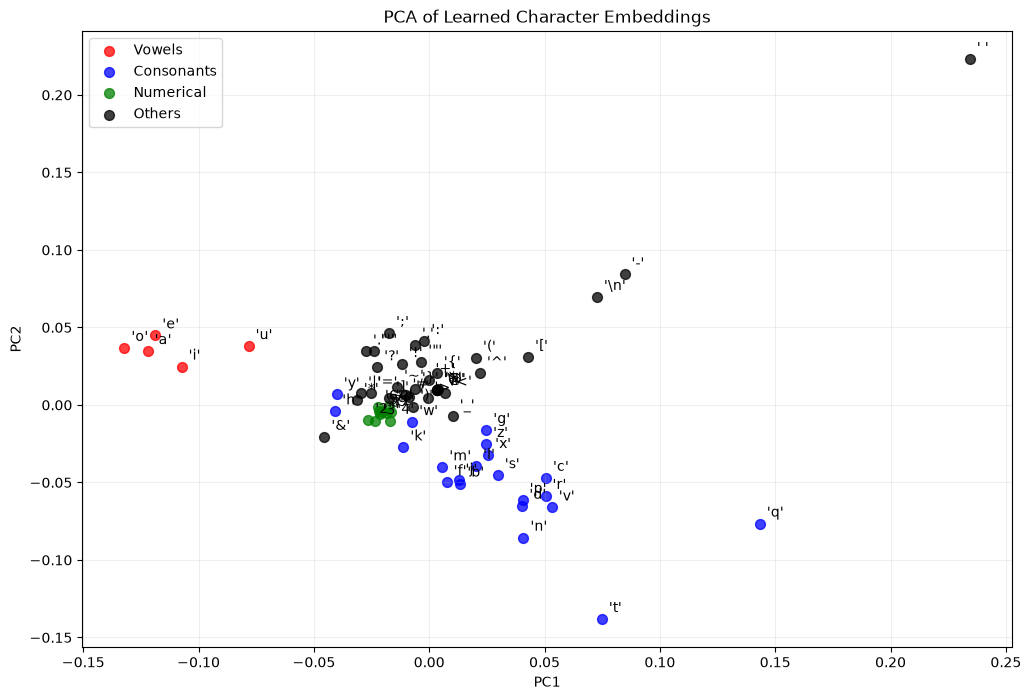

In [ ]:
plot_embedding_pca_classified(model=model, tokenizer=tokenizer)